In [87]:
import polars as pl
import polars.selectors as cs
import seaborn as sns
import numpy as np

# Preprocessing stuff
from sklearn.preprocessing import LabelEncoder 

# Model selection stuff
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV

# Classification metrics
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score

# Classification metrics
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Classic classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Useful tools for averaging cv results
import composable.records as rec

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt


# Diabetes Lab - 3.3 and 3.4

In [29]:
(folds := StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [30]:
(my_scores := ['accuracy',
          'balanced_accuracy',
          'f1',
          'precision',
          'recall',
          'roc_auc',
          ])

['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall', 'roc_auc']

In [31]:
(diabetes := pl.read_csv('data/diabetes_raw.csv')).head(2)

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes
i64,i64,i64,i64,i64,f64,f64,i64,str
6,148,72,35,0,33.6,0.627,50,"""Yes"""
1,85,66,29,0,26.6,0.351,31,"""No"""


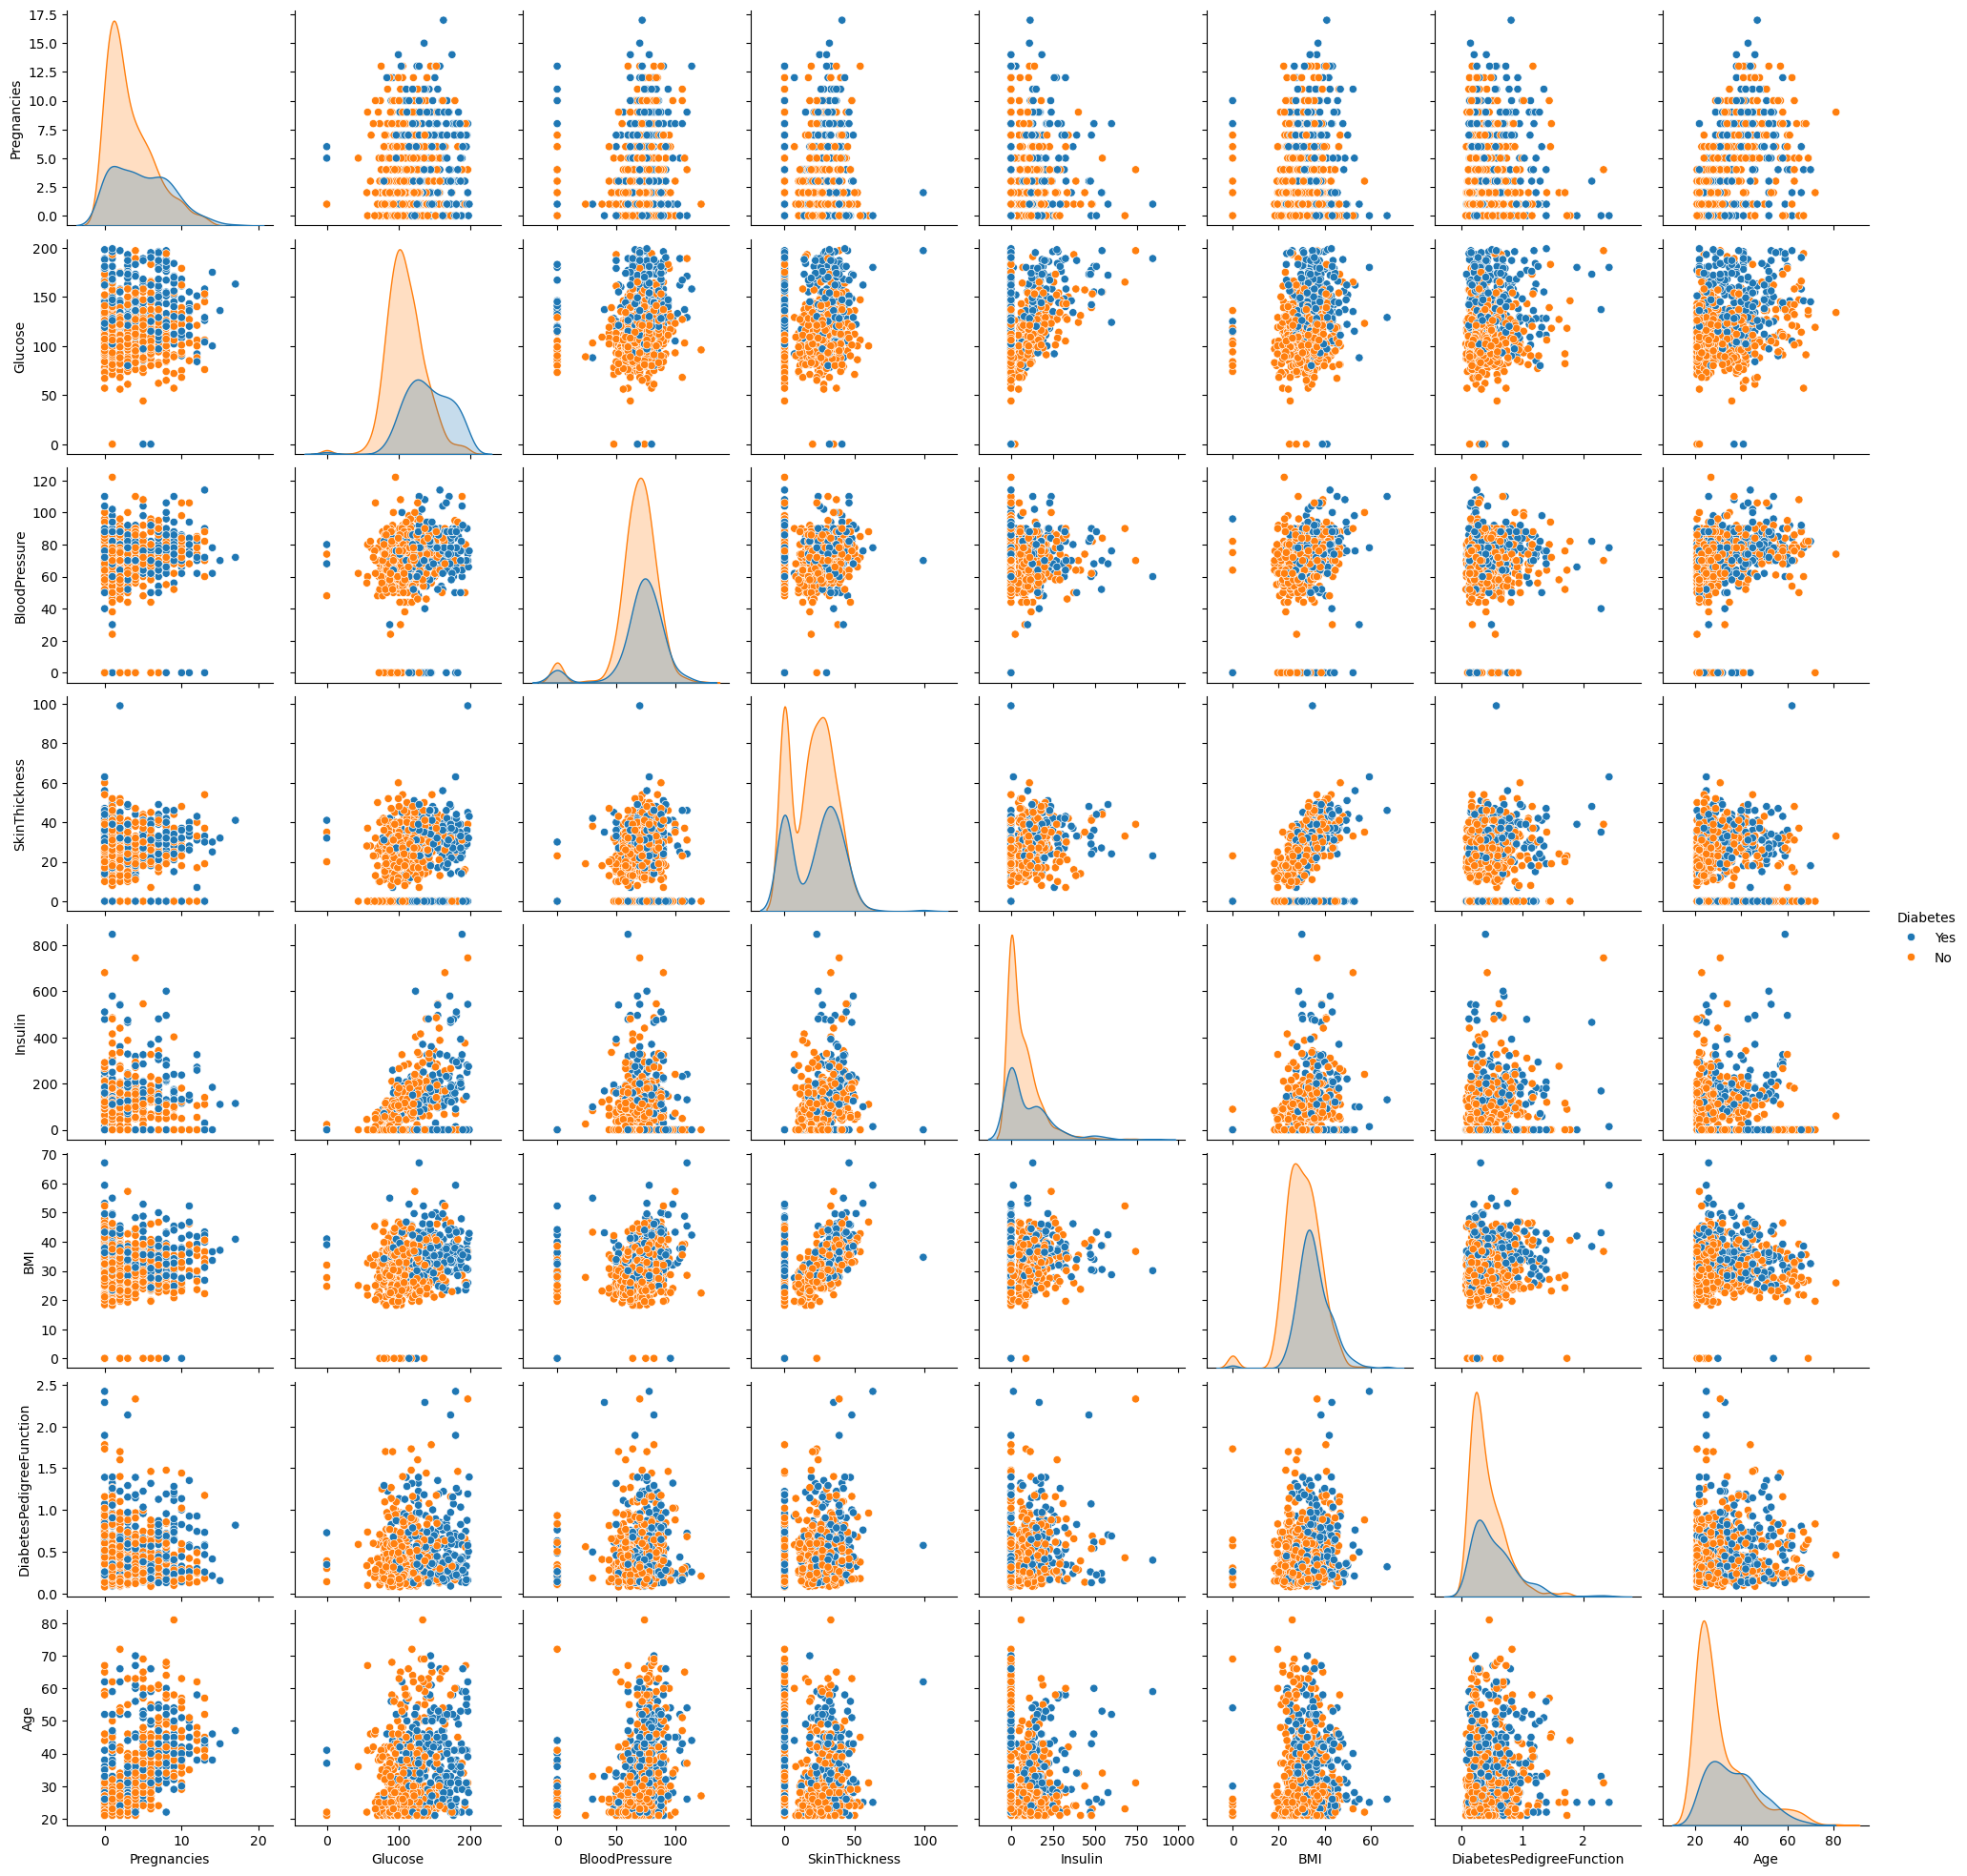

In [32]:
sns.pairplot(diabetes.to_pandas(), hue = 'Diabetes')


In [33]:
diabetes.group_by('Diabetes').len()

Diabetes,len
str,u32
"""No""",500
"""Yes""",268


In [34]:
(X_dia := diabetes
    .drop('Diabetes')
    .to_pandas())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [35]:
(y_raw_dia := diabetes.select('Diabetes'))

Diabetes
str
"""Yes"""
"""No"""
"""Yes"""
"""No"""
"""Yes"""
…
"""No"""
"""No"""
"""No"""


In [36]:
(unique_labels_dia :=
 y_raw_dia
 .unique()
 .sort(by='Diabetes',
      descending=True,  # Adjust this to get the positive case first
      )
 .to_numpy()
)

array([['Yes'],
       ['No']], dtype=object)

In [37]:
le = LabelEncoder()
le.fit(unique_labels_dia)

(y_ind_dia :=
 le.transform(y_raw_dia.to_numpy()[:, 0])
)

c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [38]:
(X_train_dia, X_test_dia, y_train_dia, y_test_dia) = train_test_split(X_dia, y_ind_dia, test_size=0.30, random_state=42, stratify=y_ind_dia)

In [42]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

In [43]:
cross_validate(log_reg, X_train_dia, y_train_dia, cv = folds, scoring=my_scores)

{'fit_time': array([0.05123544, 0.05678415, 0.02298021, 0.01813698, 0.01882339]),
 'score_time': array([0.03665209, 0.02870345, 0.02086258, 0.01416945, 0.01634669]),
 'test_accuracy': array([0.73148148, 0.7962963 , 0.77570093, 0.79439252, 0.81308411]),
 'test_balanced_accuracy': array([0.68458647, 0.73458647, 0.75212355, 0.72181467, 0.78706564]),
 'test_f1': array([0.57971014, 0.64516129, 0.67567568, 0.62068966, 0.72222222]),
 'test_precision': array([0.64516129, 0.83333333, 0.67567568, 0.85714286, 0.74285714]),
 'test_recall': array([0.52631579, 0.52631579, 0.67567568, 0.48648649, 0.7027027 ]),
 'test_roc_auc': array([0.75714286, 0.81804511, 0.83513514, 0.84826255, 0.86486486])}

In [44]:
(bayes := GaussianNB())

,priors,None
,var_smoothing,1e-09


In [45]:
cross_validate(bayes, X_train_dia, y_train_dia, cv = folds, scoring=my_scores)

{'fit_time': array([0.00686646, 0.00371099, 0.00889826, 0.00414419, 0.00434303]),
 'score_time': array([0.03027582, 0.02722549, 0.02932239, 0.03057933, 0.01794553]),
 'test_accuracy': array([0.69444444, 0.73148148, 0.77570093, 0.80373832, 0.77570093]),
 'test_balanced_accuracy': array([0.65      , 0.70263158, 0.75212355, 0.74169884, 0.73938224]),
 'test_f1': array([0.53521127, 0.61333333, 0.67567568, 0.6557377 , 0.65714286]),
 'test_precision': array([0.57575758, 0.62162162, 0.67567568, 0.83333333, 0.6969697 ]),
 'test_recall': array([0.5       , 0.60526316, 0.67567568, 0.54054054, 0.62162162]),
 'test_roc_auc': array([0.7406015 , 0.8037594 , 0.84169884, 0.83783784, 0.85135135])}

In [46]:
(QDA := QuadraticDiscriminantAnalysis())

,priors,None
,reg_param,0.0
,store_covariance,False
,tol,0.0001


In [47]:
cross_validate(QDA, X_train_dia, y_train_dia, cv = folds, scoring=my_scores)

{'fit_time': array([0.02818942, 0.01178837, 0.00471759, 0.00432658, 0.0070889 ]),
 'score_time': array([0.02992225, 0.01877403, 0.02209091, 0.03110003, 0.02225161]),
 'test_accuracy': array([0.7037037 , 0.73148148, 0.79439252, 0.80373832, 0.77570093]),
 'test_balanced_accuracy': array([0.65714286, 0.70263158, 0.76003861, 0.74169884, 0.72664093]),
 'test_f1': array([0.54285714, 0.61333333, 0.68571429, 0.6557377 , 0.63636364]),
 'test_precision': array([0.59375   , 0.62162162, 0.72727273, 0.83333333, 0.72413793]),
 'test_recall': array([0.5       , 0.60526316, 0.64864865, 0.54054054, 0.56756757]),
 'test_roc_auc': array([0.75977444, 0.79360902, 0.83281853, 0.85791506, 0.83050193])}

In [48]:
(LDA := LinearDiscriminantAnalysis())

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [49]:
cross_validate(LDA, X_train_dia, y_train_dia, cv = folds, scoring=my_scores)

{'fit_time': array([0.02663541, 0.00815964, 0.00770211, 0.006881  , 0.00830317]),
 'score_time': array([0.0230937 , 0.01898742, 0.01878858, 0.02894568, 0.02457261]),
 'test_accuracy': array([0.73148148, 0.7962963 , 0.78504673, 0.78504673, 0.80373832]),
 'test_balanced_accuracy': array([0.68458647, 0.73458647, 0.75926641, 0.70830116, 0.77355212]),
 'test_f1': array([0.57971014, 0.64516129, 0.68493151, 0.59649123, 0.70422535]),
 'test_precision': array([0.64516129, 0.83333333, 0.69444444, 0.85      , 0.73529412]),
 'test_recall': array([0.52631579, 0.52631579, 0.67567568, 0.45945946, 0.67567568]),
 'test_roc_auc': array([0.76090226, 0.81541353, 0.83088803, 0.84864865, 0.86177606])}

In [54]:
kNN = KNeighborsClassifier()
grid_knn = {'n_neighbors': [3, 5, 7, 9]}
first_score = my_scores[0]

def run_knn_grid_search_dia(primary_score):
    grid_search = GridSearchCV(
        estimator=kNN,
        param_grid=grid_knn,
        cv=folds,
        scoring=primary_score
    )
    cv_results = cross_validate(
        grid_search,
        X_train_dia,
        y_train_dia,
        cv=folds,
        scoring=my_scores
    )
    return {
        metric.replace("test_", ""): float(np.mean(values))
        for metric, values in cv_results.items()
        if metric.startswith("test_")
    }

In [55]:
(scores_dia := run_knn_grid_search_dia(first_score))

{'accuracy': 0.7281758393907927,
 'balanced_accuracy': 0.6757081893924,
 'f1': 0.5626928692657116,
 'precision': 0.640053726656897,
 'recall': 0.5028449502133713,
 'roc_auc': 0.7555354602723025}

In [56]:
(scores_by_metric_dia := {score: run_knn_grid_search_dia(score) for score in my_scores})

{'accuracy': {'accuracy': 0.7281758393907927,
  'balanced_accuracy': 0.6757081893924,
  'f1': 0.5626928692657116,
  'precision': 0.640053726656897,
  'recall': 0.5028449502133713,
  'roc_auc': 0.7555354602723025},
 'balanced_accuracy': {'accuracy': 0.7281758393907927,
  'balanced_accuracy': 0.6757081893924,
  'f1': 0.5626928692657116,
  'precision': 0.640053726656897,
  'recall': 0.5028449502133713,
  'roc_auc': 0.7555354602723025},
 'f1': {'accuracy': 0.7300449982692975,
  'balanced_accuracy': 0.6822332859174964,
  'f1': 0.57253268619935,
  'precision': 0.6370088548620251,
  'recall': 0.5244665718349929,
  'roc_auc': 0.7585084332452754},
 'precision': {'accuracy': 0.7244548286604362,
  'balanced_accuracy': 0.6690997764681975,
  'f1': 0.5510993856105169,
  'precision': 0.63754374201788,
  'recall': 0.48677098150782366,
  'roc_auc': 0.7566998577524893},
 'recall': {'accuracy': 0.7263066805122881,
  'balanced_accuracy': 0.6806502743344849,
  'f1': 0.5721650391405265,
  'precision': 0.627

#### Based on the cross-validation results, the winning model is LDA because it achieved the highest roc_auc (about 0.824), which means it had the strongest overall ability to separate positive and negative diabetes cases across classification thresholds. Logistic Regression was a very close second (about 0.820), while GaussianNB and QDA were slightly lower (both around 0.815), and KNN with grid search trailed behind (about 0.762). Since roc_auc is the “gold-standard” metric for ranking model discrimination, LDA is the best choice in this analysis: it provides the most reliable class separation performance on the diabetes training data.

In [57]:
LDA.fit(X_train_dia, y_train_dia)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [58]:
(y_pred_dia := LDA.predict(X_test_dia))

array([0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0])

In [59]:
balanced_accuracy_score(y_test_dia, y_pred_dia)

0.6864197530864198

In [60]:
f1_score(y_test_dia, y_pred_dia)

0.5774647887323944

In [61]:
roc_auc_score(y_test_dia, y_pred_dia)

0.6864197530864198

#### On the diabetes test data, the winning model achieved moderate performance, with a roc_auc and balanced_accuracy of 0.686 and an F1 score of 0.577. The alignment between roc_auc and balanced_accuracy suggests the model discriminates reasonably well across both classes, while the lower F1 reflects weaker precision-recall balance, likely driven by difficulty detecting positive diabetic cases.

## <font color="red"> Exercise 3 - Add to Lab 3.1</font>

For the `diabetes_raw.csv` data, do each of the following.

1. Plot the confusion matrix for each of the classic classification methods, and
3. Identify the model with the best value of those metrics, and interpret these winning values in the context of the problem. THE LDA and LOGISTICREGRESSION MODEL
2. Compute the sensitivity and specificity of each for winning model
4. Make a visualization of the ROC curves overlaid on each plot.

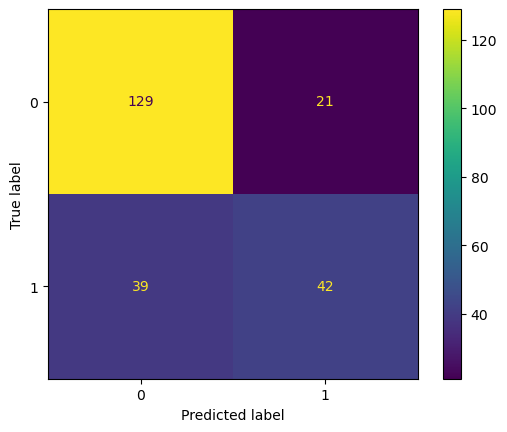

In [69]:
log_reg.fit(X_train_dia, y_train_dia)
ConfusionMatrixDisplay.from_estimator(log_reg, X_test_dia, y_test_dia)

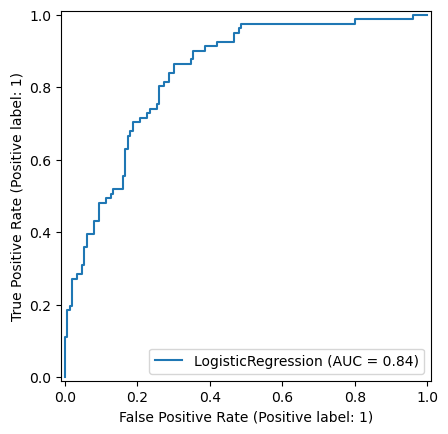

In [84]:
log_reg_disp = RocCurveDisplay.from_estimator(log_reg, X_test_dia, y_test_dia)

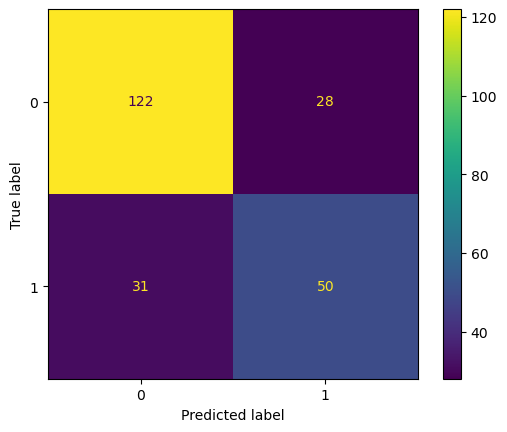

In [70]:
bayes.fit(X_train_dia, y_train_dia)
ConfusionMatrixDisplay.from_estimator(bayes, X_test_dia, y_test_dia)

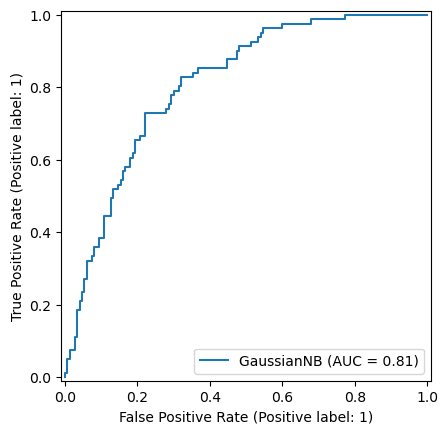

In [83]:
bayes_disp = RocCurveDisplay.from_estimator(bayes, X_test_dia, y_test_dia)

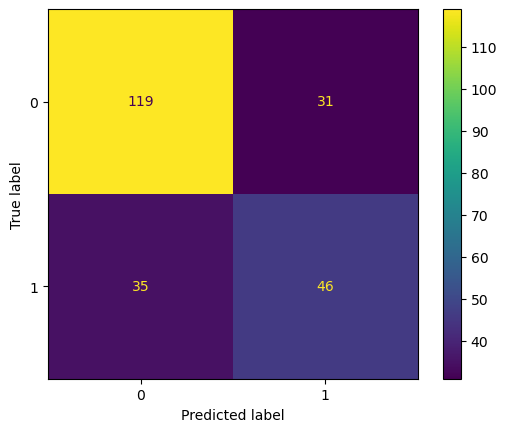

In [71]:
QDA.fit(X_train_dia, y_train_dia)
ConfusionMatrixDisplay.from_estimator(QDA, X_test_dia, y_test_dia)

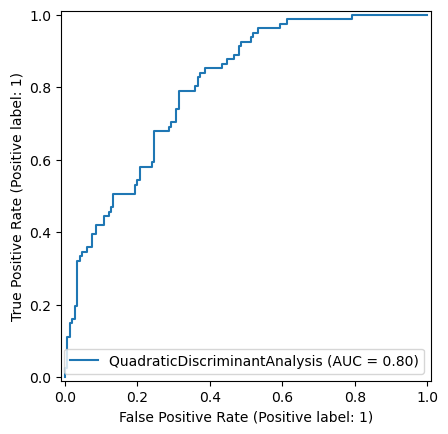

In [82]:
QDA_disp = RocCurveDisplay.from_estimator(QDA, X_test_dia, y_test_dia)

In [72]:
# Tune KNN on training data
grid_search_knn_dia = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=grid_knn,   # uses your existing {'n_neighbors': [...]}
    cv=folds,
    scoring="roc_auc"      # or "accuracy" if you prefer
)

In [73]:
grid_search_knn_dia.fit(X_train_dia, y_train_dia)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,9


In [74]:
# Best tuned model
best_knn_dia = grid_search_knn_dia.best_estimator_

In [75]:
# Predict on test data
y_pred_dia = best_knn_dia.predict(X_test_dia)

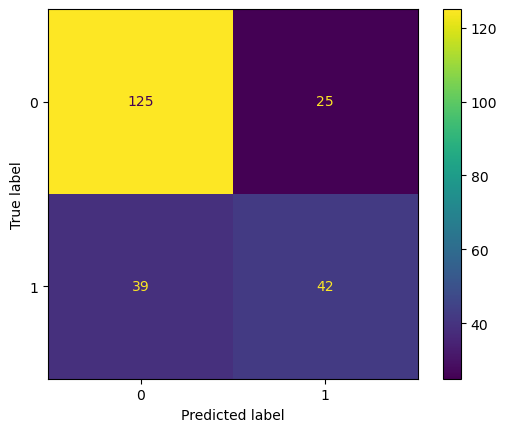

In [76]:
best_knn_dia.fit(X_train_dia, y_train_dia)
ConfusionMatrixDisplay.from_estimator(best_knn_dia, X_test_dia, y_test_dia)

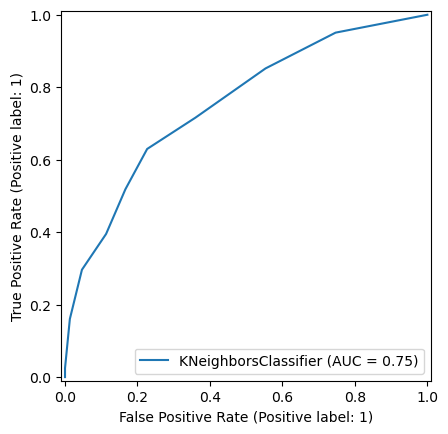

In [81]:
knn_disp = RocCurveDisplay.from_estimator(best_knn_dia, X_test_dia, y_test_dia)

## Winning Model - LDA

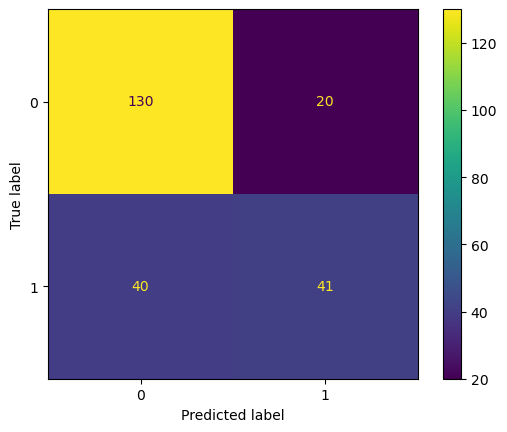

In [77]:
LDA.fit(X_train_dia, y_train_dia)
ConfusionMatrixDisplay.from_estimator(LDA, X_test_dia, y_test_dia)

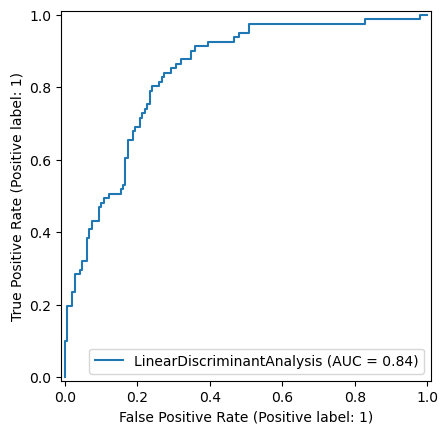

In [85]:
LDA_disp = RocCurveDisplay.from_estimator(LDA, X_test_dia, y_test_dia)

Text(0.5, 1.0, 'ROC Curves for All Models')

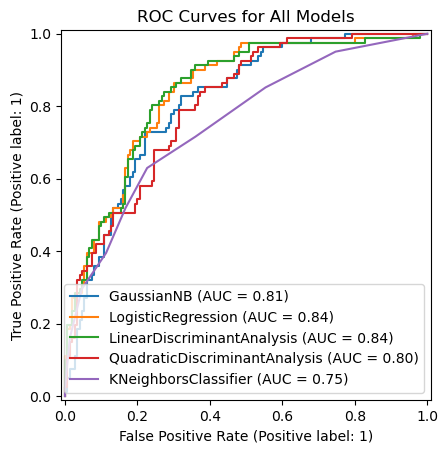

In [90]:
ax = plt.gca()
bayes_disp.plot(ax=ax)
log_reg_disp.plot(ax=ax) 
LDA_disp.plot(ax=ax)
QDA_disp.plot(ax=ax)
knn_disp.plot(ax=ax)
plt.title("ROC Curves for All Models")

# Winning Model(s)

#### Originally in the assignment for I had LDA as the winning model but when re doing in this notebook I have a tie for #1 between LogisticRegression and LDA AUC scores of 0.84. I will complete the rest of the lab for both LogisticRegression and LDA since they tied for AUC

In [110]:
# Logistic Regression
log_reg.fit(X_train_dia, y_train_dia)
y_pred_log_reg_dia = log_reg.predict(X_test_dia)
tn, fp, fn, tp = confusion_matrix(y_test_dia, y_pred_log_reg_dia).ravel().tolist()
(tn, fp, fn, tp)

(129, 21, 39, 42)

In [111]:
(log_reg_sensitivity := tp / (tp + fn))

0.5185185185185185

In [112]:
(log_reg_specificity := tn / (tn + fp))

0.86

In [113]:
# LDA
y_pred_lda_dia = LDA.predict(X_test_dia)
tn, fp, fn, tp = confusion_matrix(y_test_dia, y_pred_lda_dia).ravel().tolist()
(tn, fp, fn, tp)

(130, 20, 40, 41)

In [114]:
(lda_sensitivity := tp / (tp + fn))

0.5061728395061729

In [115]:
(lda_specificity := tn / (tn + fp))

0.8666666666666667


<font color="orange">
Logistic Regression has sensitivity 0.519 and specificity 0.860, while LDA has sensitivity 0.506 and specificity 0.867. That means both models are much better at correctly identifying non-diabetic cases (high specificity) than diabetic cases (moderate sensitivity), with Logistic Regression catching slightly more true diabetic cases and LDA being slightly better at avoiding false positives among non-diabetic cases. Overall, their performance is very similar, with a small tradeoff: Logistic Regression is a bit more sensitive, and LDA is a bit more specific.
</font>